#  Notebook 05: PD / LGD / EAD Estimation & IFRS 9 Provisioning
**BFSI Credit Risk Scorecard — Canadian Banking**  
ECL = PD × LGD × EAD × DF · Stage 1/2/3 · FLI Macro Overlay · OSFI E-6

## Overview
This notebook implements the IFRS 9 Expected Credit Loss (ECL) engine.

**IFRS 9 Three-Stage Model:**
| Stage | Description | ECL Horizon |
|-------|-------------|-------------|
| 1 | Performing — no SICR | 12-month ECL |
| 2 | Underperforming — SICR identified | Lifetime ECL |
| 3 | Non-performing / Credit-impaired | Lifetime ECL (NPL basis) |

**OSFI E-6 Adjustments (Canadian specific):**
- Downturn LGD = LGD × 1.25 (OSFI minimum scalar)
- FLI via 3 macro scenarios (BoC economic projections)
- Discount rate = BoC overnight rate + credit spread

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import sys
sys.path.insert(0, "../src")

from ifrs9_calculations import ECLCalculator, compute_provision_summary, compute_expected_loss_summary
from data_preprocessing import load_hmeq, handle_missing_values, winsorize_features, encode_categoricals
import yaml, warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
NAVY = "#003366"

In [2]:
with open("../config/config.yaml") as f:
    config = yaml.safe_load(f)

# Load full processed dataset
df_raw   = load_hmeq("../data/raw/hmeq.csv")
df_clean = handle_missing_values(df_raw, "BAD")
df_clean = winsorize_features(df_clean, "BAD")
df_clean, _ = encode_categoricals(df_clean, "BAD")

# Load champion model for PD
scorecard    = joblib.load("../models/scorecard_model.pkl")
woe_tf       = joblib.load("../models/woe_transformer.pkl")
X_woe        = woe_tf.transform(df_clean.drop(columns=["BAD"]))
df_clean["PD"] = scorecard.predict_proba(X_woe)

print(f"Portfolio size: {len(df_clean):,} accounts")
print(f"Avg PD: {df_clean['PD'].mean():.4f}")

2026-03-25 20:14:52,886 — INFO — Loading HMEQ dataset from ../data/raw/hmeq.csv


2026-03-25 20:14:52,938 — INFO — Loaded 5,960 rows × 13 columns
2026-03-25 20:14:52,940 — INFO — Dropped 0 rows with missing target
2026-03-25 20:14:52,987 — INFO — Missing value handling complete. Shape: (5960, 20)
2026-03-25 20:14:53,129 — INFO — Winsorization complete for 10 numeric features
2026-03-25 20:14:53,138 — INFO — Encoded 2 categorical features


Portfolio size: 5,960 accounts
Avg PD: 0.2008


## 1. PD Distribution Analysis

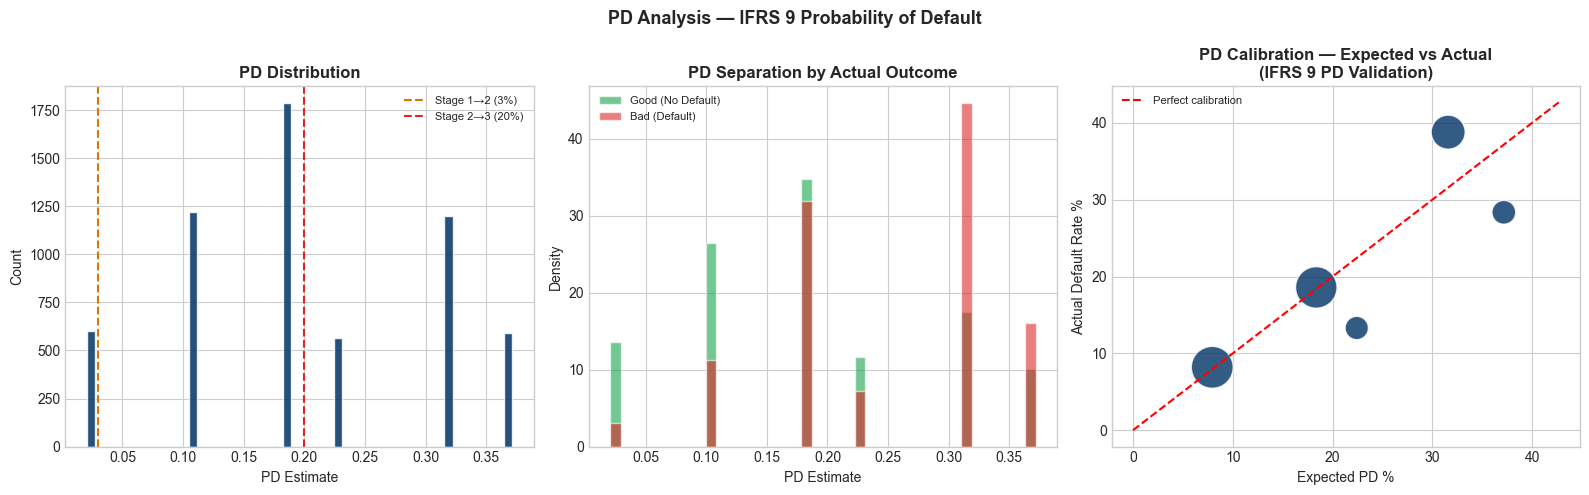

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pd_vals = df_clean["PD"].values
# PD histogram
axes[0].hist(pd_vals, bins=50, color=NAVY, edgecolor="white", alpha=0.85)
axes[0].axvline(0.03, color="#d97706", ls="--", lw=1.5, label="Stage 1→2 (3%)")
axes[0].axvline(0.20, color="#dc2626", ls="--", lw=1.5, label="Stage 2→3 (20%)")
axes[0].set_xlabel("PD Estimate"); axes[0].set_ylabel("Count")
axes[0].set_title("PD Distribution", fontweight="bold")
axes[0].legend(fontsize=8)

# PD by observed default
axes[1].hist(df_clean.loc[df_clean["BAD"]==0, "PD"], bins=40, alpha=0.6, color="#16a34a",
             density=True, label="Good (No Default)", edgecolor="white")
axes[1].hist(df_clean.loc[df_clean["BAD"]==1, "PD"], bins=40, alpha=0.6, color="#dc2626",
             density=True, label="Bad (Default)", edgecolor="white")
axes[1].set_xlabel("PD Estimate"); axes[1].set_ylabel("Density")
axes[1].set_title("PD Separation by Actual Outcome", fontweight="bold")
axes[1].legend(fontsize=8)

# PD decile vs actual default rate
df_clean["PD_Decile"] = pd.qcut(df_clean["PD"], q=10, labels=False, duplicates="drop")
decile_stats = df_clean.groupby("PD_Decile").agg(
    Expected_PD=("PD","mean"), Actual_DR=("BAD","mean"), N=("BAD","count")).reset_index()
axes[2].scatter(decile_stats["Expected_PD"]*100, decile_stats["Actual_DR"]*100,
                s=decile_stats["N"]*0.5, color=NAVY, alpha=0.8, edgecolors="white")
max_v = max(decile_stats["Expected_PD"].max(), decile_stats["Actual_DR"].max())*100*1.1
axes[2].plot([0, max_v], [0, max_v], "r--", lw=1.5, label="Perfect calibration")
axes[2].set_xlabel("Expected PD %"); axes[2].set_ylabel("Actual Default Rate %")
axes[2].set_title("PD Calibration — Expected vs Actual\n(IFRS 9 PD Validation)",fontweight="bold")
axes[2].legend(fontsize=8)

plt.suptitle("PD Analysis — IFRS 9 Probability of Default", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/05_pd_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Compute Portfolio ECL

In [4]:
calculator = ECLCalculator(config)
df_ecl     = calculator.compute_portfolio_ecl(df_clean, pd_col="PD",
                                               loan_col="LOAN", value_col="VALUE")

provision_summary = compute_provision_summary(df_ecl)
el_summary        = compute_expected_loss_summary(df_ecl, pd_col="PD")

print("\nIFRS 9 Provision Summary:")
print(provision_summary.to_string(index=False))
print(f"\nTotal EAD: ${el_summary['Total_EAD_CAD']:>20,.0f}")
print(f"Total ECL: ${el_summary['Total_ECL_CAD']:>20,.0f}")
print(f"EL Rate:   {el_summary['Portfolio_EL_Rate_%']:>20.4f}%")
print(f"Avg PD:    {el_summary['Avg_PD']:>20.4f}")
print(f"Avg LGD:   {el_summary['Avg_LGD']:>20.4f}")

2026-03-25 20:14:57,764 — INFO — Portfolio ECL computed. Stage 1: 505 | Stage 2: 71 | Stage 3: 5384
2026-03-25 20:14:57,764 — INFO — Total ECL: $8,860,877 | FLI-Adjusted ECL: $9,746,965



IFRS 9 Provision Summary:
                             Stage_Label  N_Exposures  Total_EAD  Total_ECL  Total_ECL_FLI   Avg_PD  Avg_LGD  Coverage_Ratio_%
          Stage 1 — Performing (12M ECL)          505   10210310      19666   2.163265e+04 0.020513      0.1              0.19
Stage 2 — Underperforming (Lifetime ECL)           71    1599845      25260   2.778599e+04 0.041026      0.1              1.58
 Stage 3 — Non-Performing (Lifetime ECL)         5384  111822868    8815951   9.697546e+06 0.440153      0.1              7.88

Total EAD: $         123,633,022
Total ECL: $           8,860,877
EL Rate:                 7.1671%
Avg PD:                  0.2008
Avg LGD:                 0.0800


## 3. Stage Distribution Charts

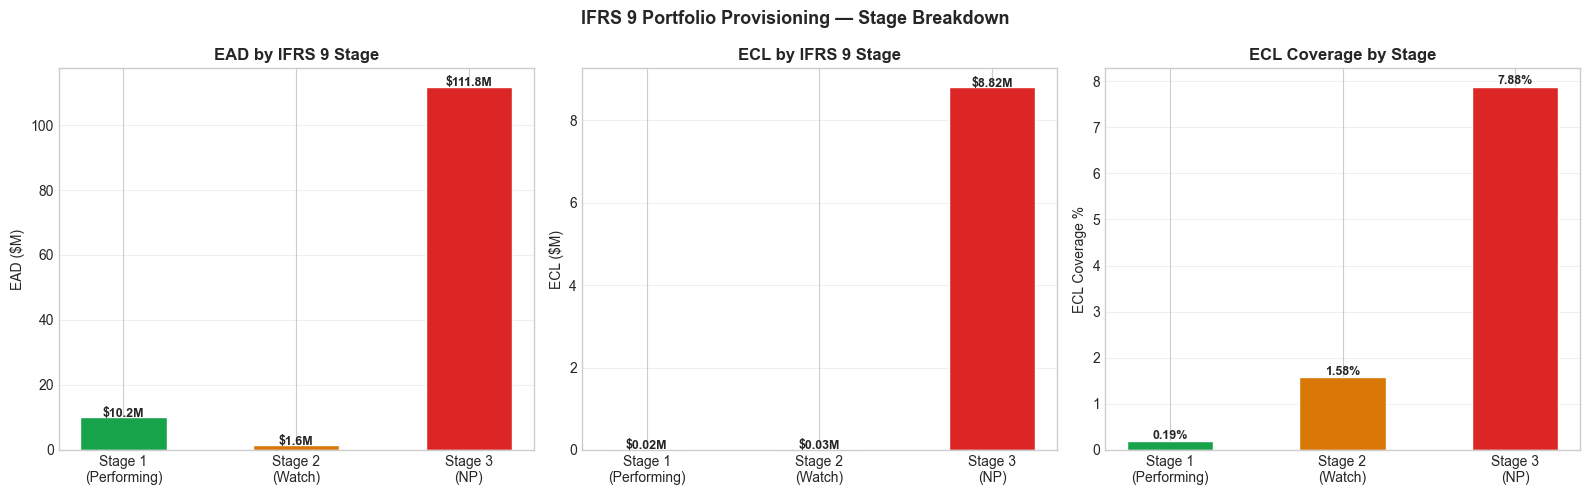

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
stage_colors = ["#16a34a", "#d97706", "#dc2626"]
stage_labels = ["Stage 1\n(Performing)", "Stage 2\n(Watch)", "Stage 3\n(NP)"]

# EAD by stage
ead_by_stage = [df_ecl[df_ecl["Stage"]==s]["EAD"].sum()/1e6 for s in [1,2,3]]
bars = axes[0].bar(stage_labels, ead_by_stage, color=stage_colors, edgecolor="white", width=0.5)
for bar, v in zip(bars, ead_by_stage):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f"${v:.1f}M", ha="center", fontweight="bold", fontsize=9)
axes[0].set_ylabel("EAD ($M)"); axes[0].set_title("EAD by IFRS 9 Stage", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# ECL by stage
ecl_by_stage = [df_ecl[df_ecl["Stage"]==s]["ECL"].sum()/1e6 for s in [1,2,3]]
bars = axes[1].bar(stage_labels, ecl_by_stage, color=stage_colors, edgecolor="white", width=0.5)
for bar, v in zip(bars, ecl_by_stage):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f"${v:.2f}M", ha="center", fontweight="bold", fontsize=9)
axes[1].set_ylabel("ECL ($M)"); axes[1].set_title("ECL by IFRS 9 Stage", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)

# Coverage ratio
cov = [df_ecl[df_ecl["Stage"]==s]["ECL_Rate"].mean()*100 for s in [1,2,3]]
bars = axes[2].bar(stage_labels, cov, color=stage_colors, edgecolor="white", width=0.5)
for bar, v in zip(bars, cov):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f"{v:.2f}%", ha="center", fontweight="bold", fontsize=9)
axes[2].set_ylabel("ECL Coverage %"); axes[2].set_title("ECL Coverage by Stage", fontweight="bold")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("IFRS 9 Portfolio Provisioning — Stage Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/05_ifrs9_staging.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. FLI Scenario Analysis

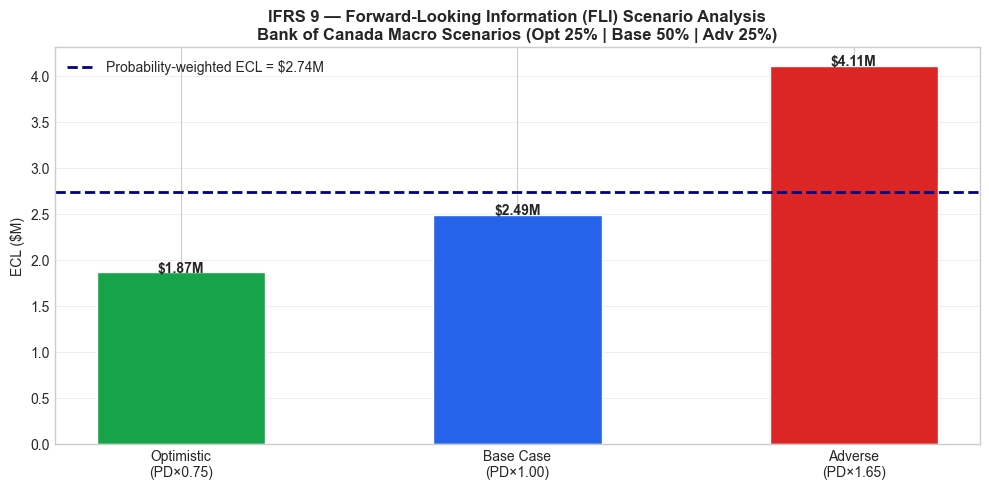

In [6]:
from ifrs9_calculations import PDModel
pd_model = PDModel(config)
scenarios = {"Optimistic\n(PD×0.75)":0.75, "Base Case\n(PD×1.00)":1.0, "Adverse\n(PD×1.65)":1.65}

fig, ax = plt.subplots(figsize=(10, 5))
ecl_scenarios = []
for label, scalar in scenarios.items():
    ecl_s = (df_ecl["PD"] * scalar * df_ecl["LGD_Downturn"] * df_ecl["EAD"]).sum()
    ecl_scenarios.append(ecl_s / 1e6)

bars = ax.bar(list(scenarios.keys()), ecl_scenarios,
              color=["#16a34a","#2563eb","#dc2626"], edgecolor="white", width=0.5)
for bar, v in zip(bars, ecl_scenarios):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"${v:.2f}M", ha="center", fontweight="bold")

# Probability-weighted
pw_weights = [0.25, 0.50, 0.25]
ecl_pw = sum(e*w for e,w in zip(ecl_scenarios, pw_weights))
ax.axhline(ecl_pw, color="navy", ls="--", lw=2,
           label=f"Probability-weighted ECL = ${ecl_pw:.2f}M")
ax.set_ylabel("ECL ($M)"); ax.grid(axis="y", alpha=0.3)
ax.set_title("IFRS 9 — Forward-Looking Information (FLI) Scenario Analysis\n"
             "Bank of Canada Macro Scenarios (Opt 25% | Base 50% | Adv 25%)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/output/05_fli_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Save Results

In [7]:
df_ecl[["Stage","PD","LGD","LGD_Downturn","EAD","ECL","ECL_FLI_Adjusted","PD_FLI_Weighted"]]\
    .to_csv("../data/processed/portfolio_ecl.csv", index=False)
provision_summary.to_csv("../data/processed/ifrs9_provision_summary.csv", index=False)

print(" IFRS 9 computation complete")
print(f"   Portfolio ECL saved: data/processed/portfolio_ecl.csv")
print(f"   Provision summary:   data/processed/ifrs9_provision_summary.csv")
print(f"\n   Stage 1 EAD: {el_summary['Stage_1_EAD_pct']:.1f}%")
print(f"   Stage 2 EAD: {el_summary['Stage_2_EAD_pct']:.1f}%")
print(f"   Stage 3 EAD: {el_summary['Stage_3_EAD_pct']:.1f}%")

 IFRS 9 computation complete
   Portfolio ECL saved: data/processed/portfolio_ecl.csv
   Provision summary:   data/processed/ifrs9_provision_summary.csv

   Stage 1 EAD: 8.3%
   Stage 2 EAD: 1.3%
   Stage 3 EAD: 90.5%
